In [1]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import rasterio
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
PROJECT_DIR = Path("/Users/rajdeepmandal/Desktop/PrithviX")

DATA_DIR = PROJECT_DIR / "Data"
PROCESSED_DIR = PROJECT_DIR / "Processed"
MODEL_DIR = PROJECT_DIR / "Models"

DEM_FILE = DATA_DIR / "DEM" / "ner_dem.tif"
NDVI_FILE = PROCESSED_DIR / "ndvi.tif"
SOIL_FILE = DATA_DIR / "Soil" / "soil.tif"
POP_FILE = DATA_DIR / "Population" / "northeastern_population.tif"

MODEL_FILE = MODEL_DIR / "landslide_xgboost.pkl"

OUTPUT_FILE = PROCESSED_DIR / "landslide_probability.tif"

print("="*60)
print("FILES")
print("="*60)

print("Model :", MODEL_FILE.exists())
print("DEM   :", DEM_FILE.exists())
print("NDVI  :", NDVI_FILE.exists())
print("SOIL  :", SOIL_FILE.exists())
print("POP   :", POP_FILE.exists())

FILES
Model : True
DEM   : True
NDVI  : True
SOIL  : True
POP   : True


In [3]:
model = joblib.load(MODEL_FILE)

print("="*60)
print("MODEL LOADED")
print("="*60)

print(type(model))

MODEL LOADED
<class 'xgboost.sklearn.XGBClassifier'>


In [4]:
with rasterio.open(DEM_FILE) as src:
    dem = src.read(1)
    profile = src.profile

with rasterio.open(NDVI_FILE) as src:
    ndvi = src.read(1)

with rasterio.open(SOIL_FILE) as src:
    soil = src.read(1)

with rasterio.open(POP_FILE) as src:
    population = src.read(1)

print("="*60)
print("RASTERS LOADED")
print("="*60)

print("DEM :", dem.shape)
print("NDVI:", ndvi.shape)
print("SOIL:", soil.shape)
print("POP :", population.shape)

RASTERS LOADED
DEM : (27474, 38963)
NDVI: (27475, 38962)
SOIL: (837, 885)
POP : (8243, 11690)


In [5]:
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np

print("="*60)
print("RESAMPLING ALL RASTERS")
print("="*60)

with rasterio.open(DEM_FILE) as src:
    dem_profile = src.profile
    target_shape = (src.height, src.width)

print("Target Shape:", target_shape)


def resample(array, source_file):
    with rasterio.open(source_file) as src:

        destination = np.empty(target_shape, dtype=np.float32)

        reproject(
            source=array,
            destination=destination,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=dem_profile["transform"],
            dst_crs=dem_profile["crs"],
            resampling=Resampling.bilinear
        )

    return destination


ndvi = resample(ndvi, NDVI_FILE)
soil = resample(soil, SOIL_FILE)
population = resample(population, POP_FILE)

print("\nDone!\n")

print("DEM :", dem.shape)
print("NDVI:", ndvi.shape)
print("SOIL:", soil.shape)
print("POP :", population.shape)
print("="*60)
print("VERIFY SHAPES")
print("="*60)

print("DEM :", dem.shape)
print("NDVI:", ndvi.shape)
print("SOIL:", soil.shape)
print("POP :", population.shape)

assert dem.shape == ndvi.shape == soil.shape == population.shape

print("\nAll rasters have identical dimensions.")

RESAMPLING ALL RASTERS
Target Shape: (27474, 38963)

Done!

DEM : (27474, 38963)
NDVI: (27474, 38963)
SOIL: (27474, 38963)
POP : (27474, 38963)
VERIFY SHAPES
DEM : (27474, 38963)
NDVI: (27474, 38963)
SOIL: (27474, 38963)
POP : (27474, 38963)

All rasters have identical dimensions.


In [6]:
import joblib
import rasterio
import numpy as np
from rasterio.windows import Window

print("="*60)
print("LOADING MODEL")
print("="*60)

MODEL_FILE = MODEL_DIR / "landslide_xgboost.pkl"
model = joblib.load(MODEL_FILE)

print("Model Loaded")

tile_size = 1024

rows, cols = dem.shape

print(f"Raster Size : {rows} x {cols}")
print(f"Tile Size   : {tile_size}")

output_file = PROCESSED_DIR / "landslide_probability.tif"

profile.update(
    dtype="float32",
    count=1,
    compress="lzw",
    nodata=-9999
)

total_tiles = (
    ((rows + tile_size - 1)//tile_size) *
    ((cols + tile_size - 1)//tile_size)
)

tile_counter = 0

with rasterio.open(output_file, "w", **profile) as dst:

    for row in range(0, rows, tile_size):

        for col in range(0, cols, tile_size):

            h = min(tile_size, rows-row)
            w = min(tile_size, cols-col)

            window = Window(col, row, w, h)

            dem_tile = dem[row:row+h, col:col+w]
            ndvi_tile = ndvi[row:row+h, col:col+w]
            soil_tile = soil[row:row+h, col:col+w]
            pop_tile = population[row:row+h, col:col+w]

            X = np.column_stack([
                dem_tile.ravel(),
                ndvi_tile.ravel(),
                soil_tile.ravel(),
                pop_tile.ravel()
            ]).astype(np.float32)

            valid = (
                np.isfinite(X[:,0]) &
                np.isfinite(X[:,1]) &
                np.isfinite(X[:,2]) &
                np.isfinite(X[:,3])
            )

            prob = np.full(X.shape[0], -9999, dtype=np.float32)

            if valid.sum() > 0:
                prob[valid] = model.predict_proba(X[valid])[:,1]

            prob = prob.reshape(h, w)

            dst.write(prob, 1, window=window)

            tile_counter += 1

            print(
                f"Tile {tile_counter}/{total_tiles}",
                end="\r"
            )

print("\n")
print("="*60)
print("PREDICTION COMPLETED")
print("="*60)

print(output_file)

LOADING MODEL
Model Loaded
Raster Size : 27474 x 38963
Tile Size   : 1024
Tile 1053/1053

PREDICTION COMPLETED
/Users/rajdeepmandal/Desktop/PrithviX/Processed/landslide_probability.tif


LANDSLIDE PROBABILITY MAP
Minimum : 2.5383585e-07
Maximum : 0.9999665
Mean    : 0.02014056


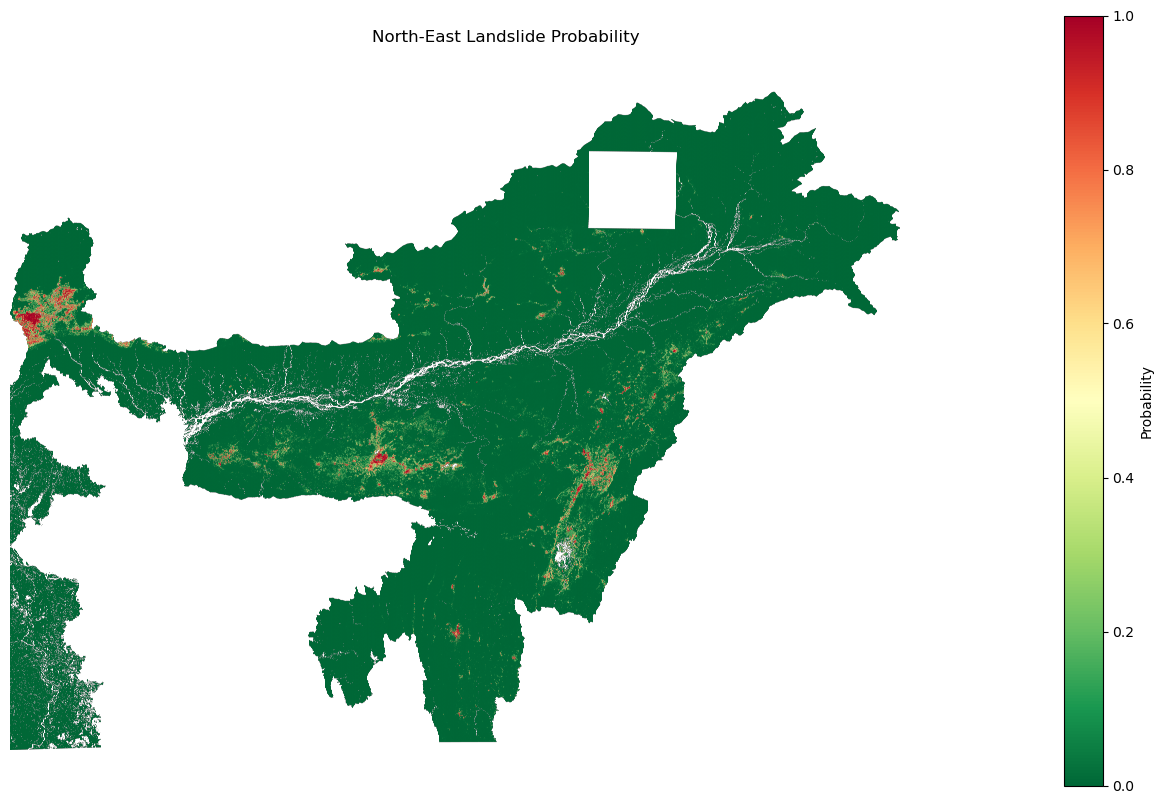

In [7]:
# ==========================================================
# Cell 8 - Visualize Landslide Probability Map
# ==========================================================

import rasterio
import numpy as np
import matplotlib.pyplot as plt

with rasterio.open(output_file) as src:
    probability = src.read(1)

# Replace NoData with NaN
probability = np.where(probability == -9999, np.nan, probability)

print("="*60)
print("LANDSLIDE PROBABILITY MAP")
print("="*60)

print("Minimum :", np.nanmin(probability))
print("Maximum :", np.nanmax(probability))
print("Mean    :", np.nanmean(probability))

plt.figure(figsize=(16,10))

plt.imshow(
    probability,
    cmap="RdYlGn_r",
    vmin=0,
    vmax=1
)

plt.colorbar(label="Probability")

plt.title("North-East Landslide Probability")

plt.axis("off")

plt.show()

Min : 2.6922015e-07
Max : 0.99991786
Mean: 0.020086724


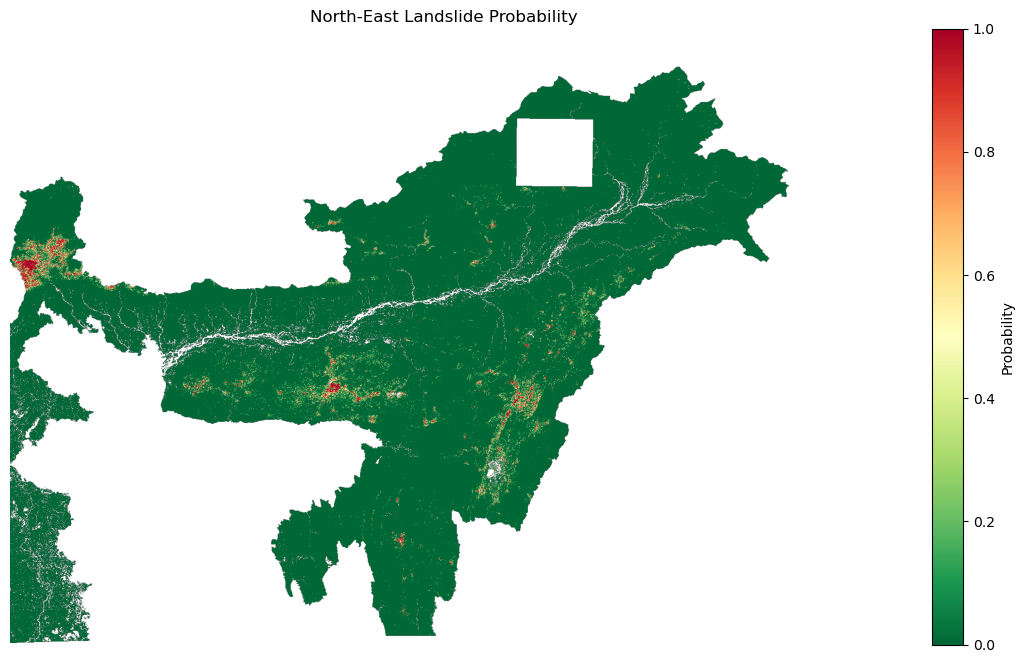

In [8]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

with rasterio.open(output_file) as src:
    probability = src.read(
        1,
        out_shape=(1, 1200, 1700)   # downsample for display
    )

probability = np.where(probability == -9999, np.nan, probability)

print("Min :", np.nanmin(probability))
print("Max :", np.nanmax(probability))
print("Mean:", np.nanmean(probability))

plt.figure(figsize=(14,8))
plt.imshow(probability, cmap="RdYlGn_r", vmin=0, vmax=1)
plt.colorbar(label="Probability")
plt.title("North-East Landslide Probability")
plt.axis("off")
plt.show()

In [9]:
# ==========================================================
# Cell 9 - Create Risk Classes
# ==========================================================

risk = np.full(probability.shape, 0, dtype=np.uint8)

risk[(probability >= 0.00) & (probability < 0.20)] = 1
risk[(probability >= 0.20) & (probability < 0.40)] = 2
risk[(probability >= 0.40) & (probability < 0.60)] = 3
risk[(probability >= 0.60) & (probability < 0.80)] = 4
risk[(probability >= 0.80)] = 5

print("="*60)
print("RISK CLASS DISTRIBUTION")
print("="*60)

names = {
    1:"Very Low",
    2:"Low",
    3:"Moderate",
    4:"High",
    5:"Very High"
}

for i in range(1,6):
    pixels = np.sum(risk==i)
    print(f"{names[i]:12} : {pixels:,} pixels")

RISK CLASS DISTRIBUTION
Very Low     : 636,210 pixels
Low          : 5,691 pixels
Moderate     : 3,664 pixels
High         : 3,343 pixels
Very High    : 5,835 pixels


In [10]:
# ==========================================================
# Cell 10 - Save Risk Map
# ==========================================================

risk_file = PROCESSED_DIR / "landslide_risk_map.tif"

profile.update(
    dtype="uint8",
    count=1,
    compress="lzw",
    nodata=0
)

with rasterio.open(risk_file, "w", **profile) as dst:
    dst.write(risk, 1)

print("="*60)
print("RISK MAP SAVED")
print("="*60)

print(risk_file)

RISK MAP SAVED
/Users/rajdeepmandal/Desktop/PrithviX/Processed/landslide_risk_map.tif


In [11]:
# ==========================================================
# Cell 11 - User Location
# ==========================================================

location = input("Enter any North-East location: ")

print("="*60)
print("LOCATION")
print("="*60)
print(location)

Enter any North-East location:  Gangtok


LOCATION
Gangtok


In [12]:
from geopy.geocoders import Nominatim

geolocator = Nominatim(user_agent="prithvix")

In [15]:
# ==========================================================
# Cell 12 - Get Coordinates using OpenWeather
# ==========================================================

import requests

OPENWEATHER_API_KEY = "9c3e8975576d1b158af0a0e9e44cc0e0"

geo_url = (
    f"http://api.openweathermap.org/geo/1.0/direct"
    f"?q={location},IN&limit=1&appid={OPENWEATHER_API_KEY}"
)

response = requests.get(geo_url)

if response.status_code != 200:
    raise Exception("Unable to connect to OpenWeather API")

data = response.json()

if len(data) == 0:
    raise Exception("Location not found!")

lat = data[0]["lat"]
lon = data[0]["lon"]
state = data[0].get("state", "Unknown")

print("="*60)
print("LOCATION FOUND")
print("="*60)

print("Location :", location)
print("State    :", state)
print("Latitude :", lat)
print("Longitude:", lon)

LOCATION FOUND
Location : Gangtok
State    : Sikkim
Latitude : 27.329046
Longitude: 88.6122673


In [16]:
import requests

# ----------------------------------------------------------
# OpenWeather API
# ----------------------------------------------------------

weather_url = (
    f"https://api.openweathermap.org/data/2.5/weather?"
    f"lat={lat}&lon={lon}"
    f"&appid={OPENWEATHER_API_KEY}"
    f"&units=metric"
)

response = requests.get(weather_url)

if response.status_code != 200:
    raise Exception("Unable to fetch weather data!")

weather = response.json()

# ----------------------------------------------------------
# Extract Weather Parameters
# ----------------------------------------------------------

temperature = weather["main"]["temp"]
feels_like = weather["main"]["feels_like"]
humidity = weather["main"]["humidity"]
pressure = weather["main"]["pressure"]

wind_speed = weather["wind"]["speed"]

rainfall = weather.get("rain", {}).get("1h", 0)

weather_main = weather["weather"][0]["main"]
description = weather["weather"][0]["description"]

# ----------------------------------------------------------
# Print
# ----------------------------------------------------------

print("="*60)
print("LIVE WEATHER REPORT")
print("="*60)

print(f"Temperature : {temperature} °C")
print(f"Feels Like  : {feels_like} °C")
print(f"Humidity    : {humidity} %")
print(f"Pressure    : {pressure} hPa")
print(f"Wind Speed  : {wind_speed} m/s")
print(f"Rainfall    : {rainfall} mm")
print(f"Condition   : {weather_main}")
print(f"Description : {description}")

LIVE WEATHER REPORT
Temperature : 27.85 °C
Feels Like  : 29.67 °C
Humidity    : 64 %
Pressure    : 1012 hPa
Wind Speed  : 2.71 m/s
Rainfall    : 0.33 mm
Condition   : Rain
Description : light rain


In [17]:
# ==========================================================
# Cell 14 - Extract Raster Values
# ==========================================================

from rasterio.transform import rowcol
import numpy as np

# Convert latitude/longitude to raster row & column
row, col = rowcol(profile["transform"], lon, lat)

print("="*60)
print("PIXEL LOCATION")
print("="*60)
print("Row    :", row)
print("Column :", col)

# Check if the point is inside the raster
if row < 0 or row >= dem.shape[0] or col < 0 or col >= dem.shape[1]:
    raise Exception("Selected location is outside the raster boundary!")

# Extract raster values
dem_value = float(dem[row, col])
ndvi_value = float(ndvi[row, col])
soil_value = float(soil[row, col])
population_value = float(population[row, col])

print("\n")
print("="*60)
print("RASTER VALUES")
print("="*60)

print(f"Elevation (DEM) : {dem_value:.2f} m")
print(f"NDVI            : {ndvi_value:.4f}")
print(f"Soil            : {soil_value:.2f}")
print(f"Population      : {population_value:.2f}")

PIXEL LOCATION
Row    : 9554
Column : 2272


RASTER VALUES
Elevation (DEM) : 1639.00 m
NDVI            : 0.2119
Soil            : 0.00
Population      : 22.72


In [18]:
# ==========================================================
# Cell 15 - Landslide Prediction
# ==========================================================

import numpy as np
import joblib

# Load your trained model
model = joblib.load(MODEL_DIR / "landslide_rf.pkl")
# If you trained XGBoost instead, replace with:
# model = joblib.load(MODEL_DIR / "landslide_xgb.pkl")

# Create feature vector
features = np.array([[
    dem_value,
    ndvi_value,
    soil_value,
    population_value
]])

# Predict
probability = model.predict_proba(features)[0][1]

print("="*60)
print("LANDSLIDE PREDICTION")
print("="*60)

print(f"Risk Probability : {probability*100:.2f}%")

LANDSLIDE PREDICTION
Risk Probability : 62.27%


In [19]:
# ==========================================================
# Cell 16 - Final Risk Report
# ==========================================================

if probability < 0.20:
    color = "🟢 GREEN"
    level = "Very Low"

elif probability < 0.40:
    color = "🟡 YELLOW"
    level = "Low"

elif probability < 0.60:
    color = "🟠 ORANGE"
    level = "Moderate"

elif probability < 0.80:
    color = "🔴 RED"
    level = "High"

else:
    color = "🟥 DARK RED"
    level = "Very High"

print("="*60)
print("PRITHVIX LANDSLIDE REPORT")
print("="*60)

print(f"Location       : {location}")
print(f"State          : {state}")
print(f"Latitude       : {lat:.6f}")
print(f"Longitude      : {lon:.6f}")

print("\n--- Weather ---")
print(f"Temperature    : {temperature:.1f} °C")
print(f"Humidity       : {humidity}%")
print(f"Pressure       : {pressure} hPa")
print(f"Wind Speed     : {wind_speed} m/s")
print(f"Rainfall       : {rainfall} mm")
print(f"Condition      : {description}")

print("\n--- Terrain ---")
print(f"Elevation      : {dem_value:.2f} m")
print(f"NDVI           : {ndvi_value:.4f}")
print(f"Soil           : {soil_value:.2f}")
print(f"Population     : {population_value:.2f}")

print("\n--- Prediction ---")
print(f"Risk Probability : {probability*100:.2f}%")
print(f"Risk Level       : {level}")
print(f"Alert            : {color}")

PRITHVIX LANDSLIDE REPORT
Location       : Gangtok
State          : Sikkim
Latitude       : 27.329046
Longitude      : 88.612267

--- Weather ---
Temperature    : 27.9 °C
Humidity       : 64%
Pressure       : 1012 hPa
Wind Speed     : 2.71 m/s
Rainfall       : 0.33 mm
Condition      : light rain

--- Terrain ---
Elevation      : 1639.00 m
NDVI           : 0.2119
Soil           : 0.00
Population     : 22.72

--- Prediction ---
Risk Probability : 62.27%
Risk Level       : High
Alert            : 🔴 RED


In [26]:
# ==========================================================
# Cell 17 - AI Landslide Analysis using OpenRouter
# ==========================================================

from openai import OpenAI

# ----------------------------------------------------------
# OpenRouter API Key
# ----------------------------------------------------------

OPENROUTER_API_KEY = "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"

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY
)

# ----------------------------------------------------------
# Prompt
# ----------------------------------------------------------
prompt = f"""
You are an AI Landslide Risk Assessment Assistant.

Using the data below, generate a concise professional disaster report.

Location: {location}, {state}

Weather:
• Temperature: {temperature:.1f} °C
• Humidity: {humidity} %
• Rainfall: {rainfall} mm
• Wind Speed: {wind_speed} m/s

Terrain:
• Elevation: {dem_value:.2f} m
• NDVI: {ndvi_value:.3f}
• Soil Index: {soil_value:.2f}
• Population Density: {population_value:.2f}

Machine Learning Prediction:
• Landslide Probability: {probability*100:.2f}%
• Risk Level: {level}

Return ONLY in this format:

====================================================
🛰️ PRITHVIX LANDSLIDE RISK REPORT
====================================================

📍 Location:
🌍 Risk Level:
🎯 Risk Probability:
🚨 Alert Colour:

🔍 Key Risk Factors:
• ...
• ...
• ...

⚠️ Immediate Precautions:
• ...
• ...
• ...

🛡️ Safety Measures:
• ...
• ...
• ...

🚑 Emergency Response Level:
(NORMAL / WATCH / ALERT / WARNING / EMERGENCY)

📢 Response Priority:
(LOW / MEDIUM / HIGH / CRITICAL)

🏛️ Recommended Authority Action:
• ...
• ...

📝 Final Recommendation:
(One short sentence only.)

Keep the response below 180 words.
Do not explain the machine learning model.
"""

# ----------------------------------------------------------
# Models to Try
# ----------------------------------------------------------

models = [

    "openai/gpt-oss-20b:free",
    "google/gemma-3-27b-it:free",
    "qwen/qwen3-30b-a3b:free",
    "mistralai/mistral-small-3.2-24b-instruct:free",

    # Paid models (if your account has access)
    "openai/gpt-4.1-mini",
    "anthropic/claude-3.5-haiku"

]

response = None

print("="*60)
print("TRYING AVAILABLE MODELS")
print("="*60)

for model_name in models:

    try:

        print(f"Trying: {model_name}")

        response = client.chat.completions.create(

            model=model_name,

            messages=[
                {
                    "role": "user",
                    "content": prompt
                }
            ],

            max_tokens=250,
            temperature=0.3

        )

        print(f"\nSUCCESS -> {model_name}")

        break

    except Exception as e:

        print(f"FAILED -> {model_name}")
        print(e)
        print()

# ----------------------------------------------------------
# Final Output
# ----------------------------------------------------------

if response is None:

    print("="*60)
    print("NO AVAILABLE MODEL FOUND")
    print("="*60)

else:

    print()
    print("="*70)
    print("AI LANDSLIDE RISK ANALYSIS")
    print("="*70)

    print(response.choices[0].message.content)

TRYING AVAILABLE MODELS
Trying: openai/gpt-oss-20b:free
FAILED -> openai/gpt-oss-20b:free
Error code: 404 - {'error': {'message': 'This model is unavailable for free. The paid version is available now - use this slug instead: openai/gpt-oss-20b', 'code': 404}, 'user_id': 'user_3ArKMCOITDruZniyBKzxCPM8Zvj'}

Trying: google/gemma-3-27b-it:free
FAILED -> google/gemma-3-27b-it:free
Error code: 404 - {'error': {'message': 'This model is unavailable for free. The paid version is available now - use this slug instead: google/gemma-3-27b-it', 'code': 404}, 'user_id': 'user_3ArKMCOITDruZniyBKzxCPM8Zvj'}

Trying: qwen/qwen3-30b-a3b:free
FAILED -> qwen/qwen3-30b-a3b:free
Error code: 404 - {'error': {'message': 'This model is unavailable for free. The paid version is available now - use this slug instead: qwen/qwen3-30b-a3b', 'code': 404}, 'user_id': 'user_3ArKMCOITDruZniyBKzxCPM8Zvj'}

Trying: mistralai/mistral-small-3.2-24b-instruct:free
FAILED -> mistralai/mistral-small-3.2-24b-instruct:free
Er